In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

import sys
import os
sys.path.append(os.path.abspath("../.."))
import utils.plot as pu

#### Standard Linear SVM in scikit-learn

<class 'sklearn.utils._bunch.Bunch'>


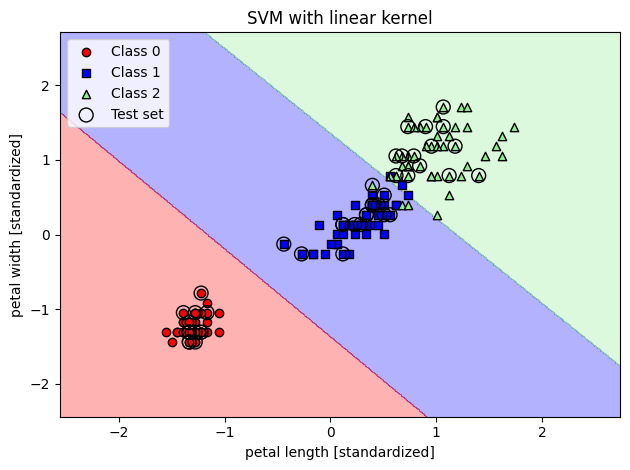

In [ ]:
# loading dataset and standadizing it
iris = datasets.load_iris()
print(type(iris))

# both x and y are numpy ndarrays
X = iris.data[:,[2,3]]
y = iris.target

# Stratify parameter= divides the training and testing data having the same proportion for each 
# label as the original dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# verification of the stratify split
# print("Labels in y : ", np.bincount(y))
# print("Labels in y_train : ", np.bincount(y_train))
# print("Labels in y_test : ", np.bincount(y_test))

sc = StandardScaler()
sc.fit(X_train)

X_std = sc.transform(X)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

# training the SVM model
svm1 = SVC(kernel='linear', C=1.0, random_state=1)
svm1.fit(X_train_std, y_train)

pu.plot_decision_regions(X_std, y, model=svm1, X_test=X_test_std)
plt.title('SVM with linear kernel')
plt.xlabel('petal length [standardized]')
plt.ylabel('petal width [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### SVM Kernel

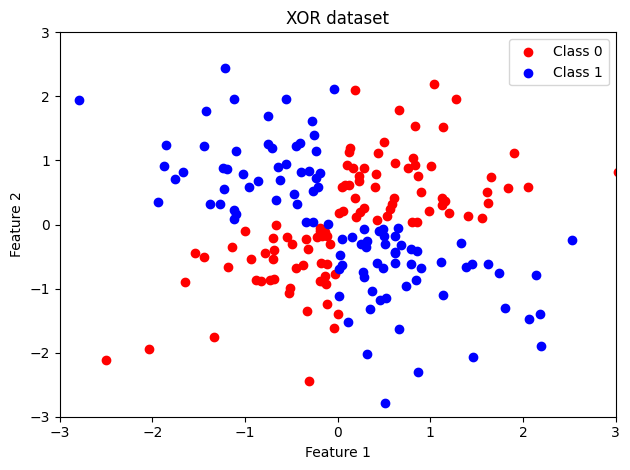

In [3]:
# generating the xor dataset
np.random.seed(1)
X_xor = np.random.randn(200, 2)
y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)
y_xor = np.where(y_xor, 1, 0)

plt.scatter(X_xor[y_xor==0][:, 0], X_xor[y_xor==0][:, 1], color='red', marker='o', label='Class 0')
plt.scatter(X_xor[y_xor==1][:, 0], X_xor[y_xor==1][:, 1], color='blue', marker='o', label='Class 1')
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.legend()
plt.title('XOR dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.tight_layout()
plt.show()

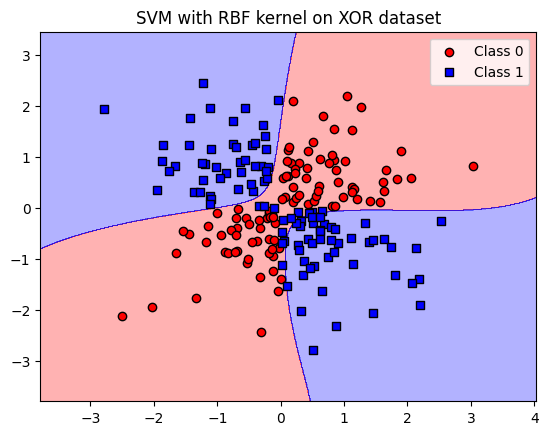

In [7]:
# training the SVM model with RBF kernel on the XOR dataset 
# Gamma controls how much influence a single data point has on the decision boundary.
# C controls the trade-off between minimizing training errors and keeping the boundary simple for better generalization.

svm2 = SVC(kernel='rbf', random_state=1, gamma=0.2, C=10.0)
svm2.fit(X_xor, y_xor)
pu.plot_decision_regions(X_xor, y_xor, model=svm2)
plt.title('SVM with RBF kernel on XOR dataset')
plt.show()

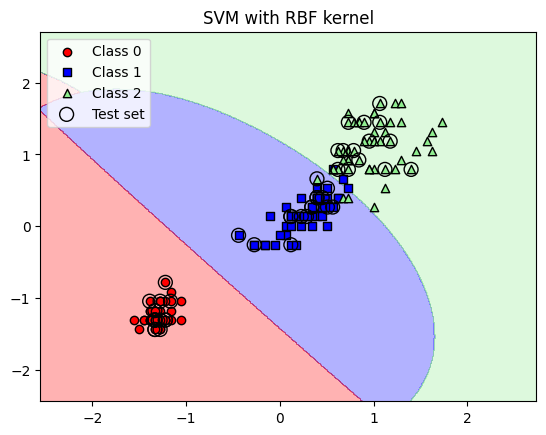

In [8]:
svm2.fit(X_train_std, y_train)
pu.plot_decision_regions(X_std, y, model=svm2, X_test=X_test_std)
plt.title('SVM with RBF kernel')
plt.show()